# Lobster Plots (Refactored)

This notebook computes and visualizes the *effective Majorana mass* $|m_{\beta\beta}|$ as a function of the lightest neutrino mass $m_l$, including statistical uncertainty from the global neutrino oscillation fit. All reusable physics functions are factored into `lobster_module.py`; this notebook handles orchestration and visualization.

---

## Physics Background

### PMNS Mixing Matrix

The Pontecorvo–Maki–Nakagawa–Sakata (PMNS) matrix $U$ relates the flavor eigenstates $(\nu_e, \nu_\mu, \nu_\tau)$ to the mass eigenstates $(\nu_1, \nu_2, \nu_3)$:

$$U = \begin{pmatrix} c_{12}c_{13} & s_{12}c_{13} & s_{13}e^{-i\delta} \\ -s_{12}c_{23} - c_{12}s_{23}s_{13}e^{i\delta} & c_{12}c_{23} - s_{12}s_{23}s_{13}e^{i\delta} & s_{23}c_{13} \\ s_{12}s_{23} - c_{12}c_{23}s_{13}e^{i\delta} & -c_{12}s_{23} - s_{12}c_{23}s_{13}e^{i\delta} & c_{23}c_{13} \end{pmatrix}$$

where $c_{ij} \equiv \cos\theta_{ij}$, $s_{ij} \equiv \sin\theta_{ij}$, and $\delta$ is the Dirac CP-violating phase.

### Majorana Phase Matrix

If neutrinos are Majorana particles, two additional CP-violating phases $\alpha_1$ and $\alpha_2$ enter through a diagonal phase matrix appended on the right:

$$U_\text{PMNS}^{\,\text{Majorana}} = U \cdot P, \qquad P = \mathrm{diag}\!\left(1,\; e^{i\alpha_1/2},\; e^{i\alpha_2/2}\right)$$

These Majorana phases are physical but entirely invisible in neutrino oscillation experiments — they appear only in lepton-number-violating processes.

### Effective Majorana Mass

The rate of neutrinoless double-beta ($0\nu\beta\beta$) decay is proportional to $|m_{\beta\beta}|^2$, where the effective Majorana mass is

$$\boxed{|m_{\beta\beta}| = \left|\, |U_{e1}|^2\, m_1 \;+\; |U_{e2}|^2\, m_2\, e^{i\alpha_1} \;+\; |U_{e3}|^2\, m_3\, e^{i\alpha_2} \,\right|}$$

with the electron-row mixing elements

$$|U_{e1}|^2 = \cos^2\!\theta_{12}\cos^2\!\theta_{13}, \qquad |U_{e2}|^2 = \sin^2\!\theta_{12}\cos^2\!\theta_{13}, \qquad |U_{e3}|^2 = \sin^2\!\theta_{13}$$

The mass eigenvalues are related to the lightest mass $m_l$ and the measured splittings:

| Ordering | $m_1$ | $m_2$ | $m_3$ |
|---|---|---|---|
| **NO** ($m_1 < m_2 < m_3$) | $m_l$ | $\sqrt{m_1^2 + \Delta m^2_{21}}$ | $\sqrt{m_1^2 + |\Delta m^2_{31}|}$ |
| **IO** ($m_3 < m_1 < m_2$) | $\sqrt{m_3^2 + |\Delta m^2_{31}|}$ | $\sqrt{m_1^2 + \Delta m^2_{21}}$ | $m_l$ |

Because $\alpha_1, \alpha_2 \in [0, 2\pi)$ are unknown, $|m_{\beta\beta}|$ sweeps out a band for each value of $m_l$. This notebook maps that band by Monte Carlo sampling of both the oscillation parameters (within their $1\sigma$ experimental ranges) and the Majorana phases.

## 1. Imports

Standard scientific Python stack (`numpy`, `pandas`, `matplotlib`) plus `lobster_module`, which contains all reusable physics, sampling, and histogram utility functions.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import lobster_module as lm

## 2. Neutrino Oscillation Parameter Data

Two data sources provide the oscillation parameters used throughout:

- **`nu_global_fit_data.txt`** — a summary table of best-fit values and asymmetric $1\sigma$ errors from the NuFIT global analysis.
- **`ahep_globalfit_chi2/1-dim/*.dat`** — per-parameter $\Delta\chi^2$ profiles for both normal (NO) and inverted (IO) ordering, used to fit parabolas and extract precise $1\sigma$ error bounds.

The code builds `params_dict_NO` / `params_dict_IO`, simple `{name: best_fit}` dictionaries used throughout to evaluate $|m_{\beta\beta}|$, as well as `df_NO` / `df_IO` DataFrames that carry the full $1\sigma$ error information needed for Monte Carlo sampling.

In [3]:
nu_global_fit_data = lm.ingest_nu_global_fit_data("nu_global_fit_data.txt")
df_global_fit = pd.DataFrame(nu_global_fit_data["rows"])
df_global_fit.head()

,parameter,central,err_minus,err_plus,sigma2_range,sigma3_range
0,\Delta m^2_{21}: [10^{-5} eV^2],7.50,0.20,0.22,7.11–7.93,6.94–8.14
1,|\Delta m^2_{31}|: [10^{-3} eV^2] (NO),2.55,0.03,0.02,2.49–2.60,2.47–2.63
2,|\Delta m^2_{31}|: [10^{-3} eV^2] (IO),2.45,0.03,0.02,2.39–2.50,2.37–2.53
3,\sin^2\theta_{12} / 10^{-1},3.18,0.16,0.16,2.86–3.52,2.71–3.69
4,\sin^2\theta_{23} / 10^{-1} (NO),5.74,0.14,0.14,5.41–5.99,4.34–6.10


In [4]:
df_NO, df_IO = lm.build_globalfit_tables(data_path="./ahep_globalfit_chi2/1-dim/")
params_dict_NO = lm.params_dict_from_df(df_NO)
params_dict_IO = lm.params_dict_from_df(df_IO)

display(df_NO.head())
display(df_IO.head())

,Param,BestFit,ErrorMinus,ErrorPlus
0,del,1.096264,0.970361,1.222167
1,dm21,0.000075,0.000073,0.000077
2,dm31,0.002546,0.002520,0.002573
3,sq12,0.318467,0.302182,0.334752
4,sq13,0.022019,0.021339,0.022699


,Param,BestFit,ErrorMinus,ErrorPlus
0,del,1.566940,1.415725,1.718155
1,dm21,0.000075,0.000073,0.000077
2,dm31,0.002448,0.002420,0.002475
3,sq12,0.318467,0.302182,0.334752
4,sq13,0.022198,0.021522,0.022874


In [5]:
from IPython.display import Markdown

# Human-readable labels, display units, scale factor, and decimal places for each parameter.
param_display = {
    "dm21": (r"$\Delta m^2_{21}$",         r"$\times 10^{-5}\ \mathrm{eV}^2$", 1e5, 4),
    "dm31": (r"$\|\Delta m^2_{31}\|$",     r"$\times 10^{-3}\ \mathrm{eV}^2$", 1e3, 4),
    "sq12": (r"$\sin^2\!\theta_{12}$",      "",                                  1.0, 4),
    "sq13": (r"$\sin^2\!\theta_{13}$",      "",                                  1.0, 5),
    "sq23": (r"$\sin^2\!\theta_{23}$",      "",                                  1.0, 4),
    "del":  (r"$\delta_\mathrm{CP}$",       "rad",                               1.0, 3),
}

no = df_NO.set_index("Param")
io = df_IO.set_index("Param")

header = "| Parameter | Units | NO best fit | NO $-1\\sigma$ | NO $+1\\sigma$ | IO best fit | IO $-1\\sigma$ | IO $+1\\sigma$ |"
sep = "|:---|:---|---:|---:|---:|---:|---:|---:|"
rows = [header, sep]

for p, (label, unit, scale, dec) in param_display.items():
    if p not in no.index or p not in io.index:
        continue
    r_no, r_io = no.loc[p], io.loc[p]

    # ErrorMinus / ErrorPlus are absolute parameter values at the ±1σ chi² = 1 crossings.
    def fv(v):
        return f"{v * scale:.{dec}f}"

    rows.append(
        f"| {label} | {unit} "
        f"| {fv(r_no.BestFit)} | {fv(r_no.BestFit - r_no.ErrorMinus)} | {fv(r_no.ErrorPlus - r_no.BestFit)} "
        f"| {fv(r_io.BestFit)} | {fv(r_io.BestFit - r_io.ErrorMinus)} | {fv(r_io.ErrorPlus - r_io.BestFit)} |"
    )

# Escape literal pipes in the markdown table labels so Markdown doesn't split columns.
display(Markdown("**Oscillation parameter best fits with $1\\sigma$ uncertainties (from $\\Delta\\chi^2 = 1$ profiles)**\n\n" + "\n".join(rows)))

**Oscillation parameter best fits with $1\sigma$ uncertainties (from $\Delta\chi^2 = 1$ profiles)**

| Parameter | Units | NO best fit | NO $-1\sigma$ | NO $+1\sigma$ | IO best fit | IO $-1\sigma$ | IO $+1\sigma$ |
|:---|:---|---:|---:|---:|---:|---:|---:|
| $\Delta m^2_{21}$ | $\times 10^{-5}\ \mathrm{eV}^2$ | 7.5039 | 0.2117 | 0.2117 | 7.5039 | 0.2117 | 0.2117 |
| $\|\Delta m^2_{31}\|$ | $\times 10^{-3}\ \mathrm{eV}^2$ | 2.5464 | 0.0269 | 0.0269 | 2.4476 | 0.0278 | 0.0278 |
| $\sin^2\!\theta_{12}$ |  | 0.3185 | 0.0163 | 0.0163 | 0.3185 | 0.0163 | 0.0163 |
| $\sin^2\!\theta_{13}$ |  | 0.02202 | 0.00068 | 0.00068 | 0.02220 | 0.00068 | 0.00068 |
| $\sin^2\!\theta_{23}$ |  | 0.5731 | 0.0138 | 0.0138 | 0.5730 | 0.0134 | 0.0134 |
| $\delta_\mathrm{CP}$ | rad | 1.096 | 0.126 | 0.126 | 1.567 | 0.151 | 0.151 |

## 3. Best-Fit Lobster Plot (Single Phase)

A quick sanity-check: $|m_{\beta\beta}|(m_l)$ evaluated at best-fit oscillation parameters with Majorana phases fixed to zero. This traces the central value of the allowed band for each mass ordering and confirms the parameter ingestion is working correctly.

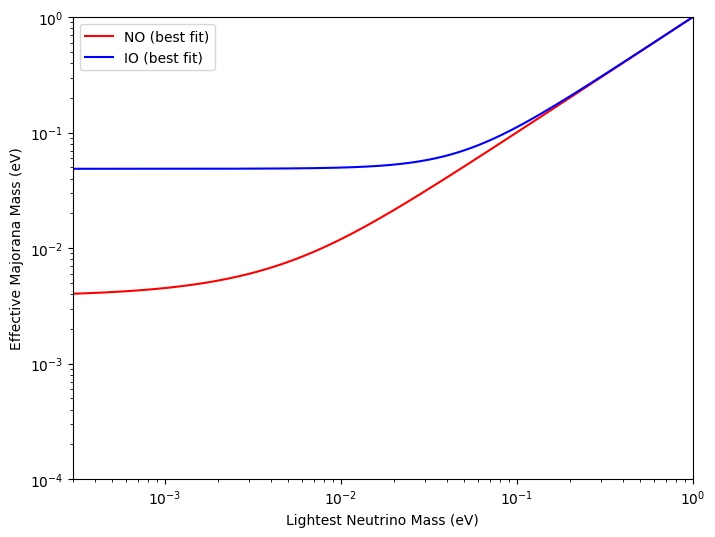

In [6]:
m_l = np.logspace(-4.0, 0.0, 300)
mbb_NO = lm.majorana_mass(params_dict_NO, ordering="NO", m_l=m_l)
mbb_IO = lm.majorana_mass(params_dict_IO, ordering="IO", m_l=m_l)

plt.figure(figsize=(8, 6))
plt.plot(m_l, mbb_NO, color="red", label="NO (best fit)")
plt.plot(m_l, mbb_IO, color="blue", label="IO (best fit)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Lightest Neutrino Mass (eV)")
plt.ylabel("Effective Majorana Mass (eV)")
plt.xlim(3e-4, 1.0)
plt.ylim(1e-4, 1.0)
plt.legend()
plt.show()

## 4. Monte Carlo Sample Generation

To map the full probability density of $|m_{\beta\beta}|(m_l)$, oscillation parameters are drawn uniformly within their $1\sigma$ experimental ranges, and the Majorana phases are drawn uniformly over $[0, 2\pi)$. This is repeated for each point on a logarithmic $m_l$ grid.

The resulting $(m_l,\, m_{\beta\beta})$ point cloud is cached in `mbb_density_samples.pkl`. On subsequent runs, the cache is reloaded automatically to skip the expensive sampling step.

In [7]:
cache_path = "mbb_density_samples.pkl"
m_l_grid = np.logspace(-4.0, 0.0, 120)
n_samples_per_m = 500

if os.path.exists(cache_path):
    cache_payload = lm.load_sample_cache(cache_path)

    m_l_grid = cache_payload.get("m_l_grid", cache_payload.get("m_l_values", m_l_grid))
    m_NO_pts = cache_payload.get("m_NO_pts", cache_payload.get("m_NO"))
    mbb_NO_pts = cache_payload.get("mbb_NO_pts", cache_payload.get("mbb_NO"))
    m_IO_pts = cache_payload.get("m_IO_pts", cache_payload.get("m_IO"))
    mbb_IO_pts = cache_payload.get("mbb_IO_pts", cache_payload.get("mbb_IO"))

    # Backward compatibility for older cache payloads.
    if m_NO_pts is None or mbb_NO_pts is None:
        m_NO_pts = cache_payload.get("m_NO_samples", cache_payload.get("m_no"))
        mbb_NO_pts = cache_payload.get("mbb_NO_samples", cache_payload.get("mbb_no"))
    if m_IO_pts is None or mbb_IO_pts is None:
        m_IO_pts = cache_payload.get("m_IO_samples", cache_payload.get("m_io"))
        mbb_IO_pts = cache_payload.get("mbb_IO_samples", cache_payload.get("mbb_io"))

    if m_NO_pts is None or mbb_NO_pts is None or m_IO_pts is None or mbb_IO_pts is None:
        raise KeyError("Cache file exists but does not contain recognized sample keys.")

    cfg = cache_payload.get("config", {})
    if "m_grid" in cfg:
        m_l_grid = np.asarray(cfg["m_grid"])
else:
    rng = np.random.default_rng(7)
    m_NO_pts, mbb_NO_pts = lm.generate_mbb_density_samples(
        params_dict_NO,
        df_ref=df_NO,
        ordering="NO",
        m_l_grid=m_l_grid,
        n_samples_per_m=n_samples_per_m,
        rng=rng,
    )
    m_IO_pts, mbb_IO_pts = lm.generate_mbb_density_samples(
        params_dict_IO,
        df_ref=df_IO,
        ordering="IO",
        m_l_grid=m_l_grid,
        n_samples_per_m=n_samples_per_m,
        rng=rng,
    )

    lm.save_sample_cache(
        cache_path,
        {
            "m_l_grid": m_l_grid,
            "m_NO_pts": m_NO_pts,
            "mbb_NO_pts": mbb_NO_pts,
            "m_IO_pts": m_IO_pts,
            "mbb_IO_pts": mbb_IO_pts,
        },
    )

len(m_NO_pts), len(m_IO_pts)

(137500, 137500)

## 5. Histogram Setup and Plotting Helpers

The raw $(m_l,\, m_{\beta\beta})$ sample pairs are binned into a 2D histogram. The $x$-bins are constructed to align exactly with the sampled $m_l$ grid points (avoiding empty-column artifacts), and the $y$-bins span the full $m_{\beta\beta}$ range logarithmically.

This cell also defines:
- **Physical constants** and XLZD half-life assumptions for 80 t and 60 t exposures.
- `mbb_band_from_halflife` — converts a $(T_{1/2}^{\text{range}},\; \text{NME range})$ pair into an $m_{\beta\beta}$ band via $|m_{\beta\beta}| = (G g_A^4 |M_{0\nu}|^2 T_{1/2})^{-1/2} m_e$.
- `build_mbb_bands(nme_band, mode)` — returns $(m_{\beta\beta}^{80\text{t}},\, m_{\beta\beta}^{60\text{t}})$ bands for `mode="sensitivity"` or `mode="discovery"`.
- `plot_four_panel_for_bands` — the core 4-panel figure routine called by §§6a–6d.

In [8]:
# Shared setup for 4-panel lobster plots and a reusable plotting helper.
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter

_fmt = FuncFormatter(lambda x, _: f"{x:g}")

# Build x-bins directly from sampled m_l values to avoid grid-mismatch artifacts.
x_grid_from_samples = np.unique(np.concatenate([m_NO_pts, m_IO_pts]))
x_bins = lm.x_edges_from_grid(x_grid_from_samples)
y_bins = np.logspace(-1.0, 3.0, 400) * 1e-3

hist = lm.compute_density_histograms(m_NO_pts, mbb_NO_pts, m_IO_pts, mbb_IO_pts, x_bins, y_bins)

# CP-conserving / mu-tau reflection-symmetry phase-curve overlays (theta23, delta_CP
# drop out of m_bb, so these four curves are also mu-tau reflection symmetry's full
# prediction for m_bb -- see Section 7 below).
m_l_model_eV = np.logspace(-4.0, 0.0, 400)
m_l_model_meV = m_l_model_eV * 1e3
model_curves_no = lm.cp_conserving_curves(params_dict_NO, "NO", m_l_model_eV)
model_curves_io = lm.cp_conserving_curves(params_dict_IO, "IO", m_l_model_eV)

# Shared constants for translating T1/2 bands to m_bb bands.
G = 14.58e-15
g_A = 1.273
m_e = 0.511e6

# XLZD exposure assumptions.
halflife_sens_80t = {"upper": 1.3e28, "lower": 8.6e27}
halflife_disc_80t = {"upper": 5.76e27, "lower": 3.81e27}
halflife_sens_60t = {"upper": 9.4e27, "lower": 6.2e27}
halflife_disc_60t = {"upper": 4.06e27, "lower": 2.64e27}

# NME ranges.
nme_ab_initio = {"lower": 1.08, "upper": 1.90}
nme_pheno = {"lower": 1.98, "upper": 5.06}


def mbb_band_from_halflife(nme_band, t_half_band):
    return {
        "upper": np.sqrt(1.0 / (G * g_A**4 * nme_band["upper"] ** 2 * t_half_band["upper"])) * m_e,
        "lower": np.sqrt(1.0 / (G * g_A**4 * nme_band["lower"] ** 2 * t_half_band["lower"])) * m_e,
    }


def build_mbb_bands(nme_band, mode):
    if mode == "sensitivity":
        t80 = halflife_sens_80t
        t60 = halflife_sens_60t
    elif mode == "discovery":
        t80 = halflife_disc_80t
        t60 = halflife_disc_60t
    else:
        raise ValueError("mode must be 'sensitivity' or 'discovery'")

    mbb_80t = mbb_band_from_halflife(nme_band, t80)
    mbb_60t = mbb_band_from_halflife(nme_band, t60)
    return mbb_80t, mbb_60t


def plot_four_panel_for_bands(mbb_80t, mbb_60t, title_prefix):
    probs_local = lm.discovery_probabilities(
        hist["H_no_pdf"],
        hist["H_io_pdf"],
        hist["y_edges"],
        mbb_80t,
        mbb_60t,
    )

    # Cosmology limits from the legacy notebook (DESI w0-wa): sum_m_nu = 0.163 eV.
    try:
        m_l_no_max, m_l_io_max = lm.cosmological_lightest_limits(0.163, params_dict_NO, params_dict_IO)
    except ValueError:
        m_l_no_max = lm.solve_lightest_from_sum(0.163, params_dict_NO["dm21"], params_dict_NO["dm31"], ordering="NO")
        m_l_io_max = np.nan

    x_edges_meV = hist["x_edges"] * 1e3
    y_edges_meV = hist["y_edges"] * 1e3
    x_centers_meV = 0.5 * (x_edges_meV[:-1] + x_edges_meV[1:])
    m_l_no_max_meV = m_l_no_max * 1e3
    m_l_io_max_meV = m_l_io_max * 1e3 if np.isfinite(m_l_io_max) else np.nan

    mbb_80t_meV = {k: v * 1e3 for k, v in mbb_80t.items()}
    mbb_60t_meV = {k: v * 1e3 for k, v in mbb_60t.items()}

    fig, axes = plt.subplots(
        2, 2, figsize=(14, 8),
        sharex="col",
        gridspec_kw={"height_ratios": [1.5, 1]},
        constrained_layout=True,
    )

    uniform_cmap = plt.get_cmap("viridis").copy()
    uniform_cmap.set_bad(alpha=0.0)
    norm_col = LogNorm(vmin=hist["vmin"], vmax=hist["vmax"])

    def add_cosmology_exclusion(ax, x_lim_right, cutoff_meV):
        if not np.isfinite(cutoff_meV):
            return
        ax.axvspan(cutoff_meV, x_lim_right, facecolor="white", alpha=0.32, hatch="///", edgecolor="0.4", linewidth=0.0)
        ax.axvline(cutoff_meV, color="0.2", linestyle="--", linewidth=1.2)

    def add_xlzd_bands(ax):
        ax.fill_between(x_edges_meV, mbb_80t_meV["upper"], mbb_80t_meV["lower"], color="gray", alpha=0.35, label="XLZD 80 t")
        ax.fill_between(x_edges_meV, mbb_60t_meV["upper"], mbb_60t_meV["lower"], color="orange", alpha=0.35, label="XLZD 60 t")

    def add_model_curves(ax, curves):
        ax.plot(m_l_model_meV, curves["(0, 0)"], color="black", lw=1.6, ls="-", label=r"$\mu\tau$-refl. sym. (max)")
        ax.plot(m_l_model_meV, curves["(0, pi)"], color="black", lw=1.6, ls="--", label=r"$\mu\tau$-refl. sym. (min)")

    # Top-left: NO density
    ax = axes[0, 0]
    pcm_no = ax.pcolormesh(x_edges_meV, y_edges_meV, hist["H_no_pdf_masked"].T, shading="auto", cmap=uniform_cmap, norm=norm_col)
    ax.set_title(f"{title_prefix}: Normal ordering")
    ax.set_yscale("log")
    ax.set_ylabel(r"$m_{\beta\beta}$ (meV)")
    ax.set_xlim(2e-1, 2e2)
    ax.set_ylim(3e-1, 2e2)
    add_xlzd_bands(ax)
    add_model_curves(ax, model_curves_no)
    add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_no_max_meV)
    ax.text(1.08 * m_l_no_max_meV, 3.9e-1, 'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
    ax.legend(loc="upper left", fontsize=8.8, frameon=False)
    ax.yaxis.set_major_formatter(_fmt)
    cb_no = fig.colorbar(pcm_no, ax=ax)
    cb_no.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

    # Top-right: IO density
    ax = axes[0, 1]
    pcm_io = ax.pcolormesh(x_edges_meV, y_edges_meV, hist["H_io_pdf_masked"].T, shading="auto", cmap=uniform_cmap, norm=norm_col)
    ax.set_title(f"{title_prefix}: Inverted ordering")
    ax.set_yscale("log")
    ax.set_ylabel(r"$m_{\beta\beta}$ (meV)")
    ax.set_xlim(2e-1, 2e2)
    ax.set_ylim(3e-1, 2e2)
    add_xlzd_bands(ax)
    add_model_curves(ax, model_curves_io)
    add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_io_max_meV)
    if np.isfinite(m_l_io_max_meV):
        ax.text(1.08 * m_l_io_max_meV, 3.9e-1, 'Excl. by $w_0 w_a$\ncosmology', fontsize=9.2, color='0.2', rotation=0, va='bottom')
    ax.legend(loc="upper left", fontsize=8.8, frameon=False)
    ax.yaxis.set_major_formatter(_fmt)
    cb_io = fig.colorbar(pcm_io, ax=ax)
    cb_io.set_label(r"$p(m_{\beta\beta}\,|\,m_l)$ per bin")

    # Bottom-left: NO probability
    ax = axes[1, 0]
    add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_no_max_meV)
    ax.plot(x_centers_meV, probs_local["no_80t"], color="gray", lw=1.9, label="80 t")
    ax.plot(x_centers_meV, probs_local["no_60t"], color="orange", lw=1.9, label="60 t")
    ax.set_xscale("log")
    ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
    ax.set_ylabel("P")
    ax.set_xlim(2e-1, 2e2)
    ax.set_ylim(0.0, 1.05)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(_fmt)

    # Bottom-right: IO probability
    ax = axes[1, 1]
    add_cosmology_exclusion(ax, x_edges_meV[-1], m_l_io_max_meV)
    ax.plot(x_centers_meV, probs_local["io_80t"], color="gray", lw=1.9, label="80 t")
    ax.plot(x_centers_meV, probs_local["io_60t"], color="orange", lw=1.9, label="60 t")
    ax.set_xscale("log")
    ax.set_xlabel(r"Lightest neutrino mass $m_l$ (meV)")
    ax.set_ylabel("P")
    ax.set_xlim(2e-1, 2e2)
    ax.set_ylim(0.0, 1.05)
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    ax.xaxis.set_major_formatter(_fmt)

    plt.show()


## 6a. Ab-initio NMEs — Sensitivity Reach

The **sensitivity** half-lives represent the $m_{\beta\beta}$ values at which XLZD would begin to exclude signal at 90% CL ($T^{1/2}_{80\text{t}} \in [8.6,\,13]\times10^{27}$ yr, $T^{1/2}_{60\text{t}} \in [6.2,\,9.4]\times10^{27}$ yr). The NME uncertainty is taken from ab-initio shell-model calculations ($|M_{0\nu}| \in [1.08,\,1.90]$). The hatched region is excluded by the DESI $w_0 w_a$ cosmological bound $\Sigma m_\nu < 0.163$ eV.

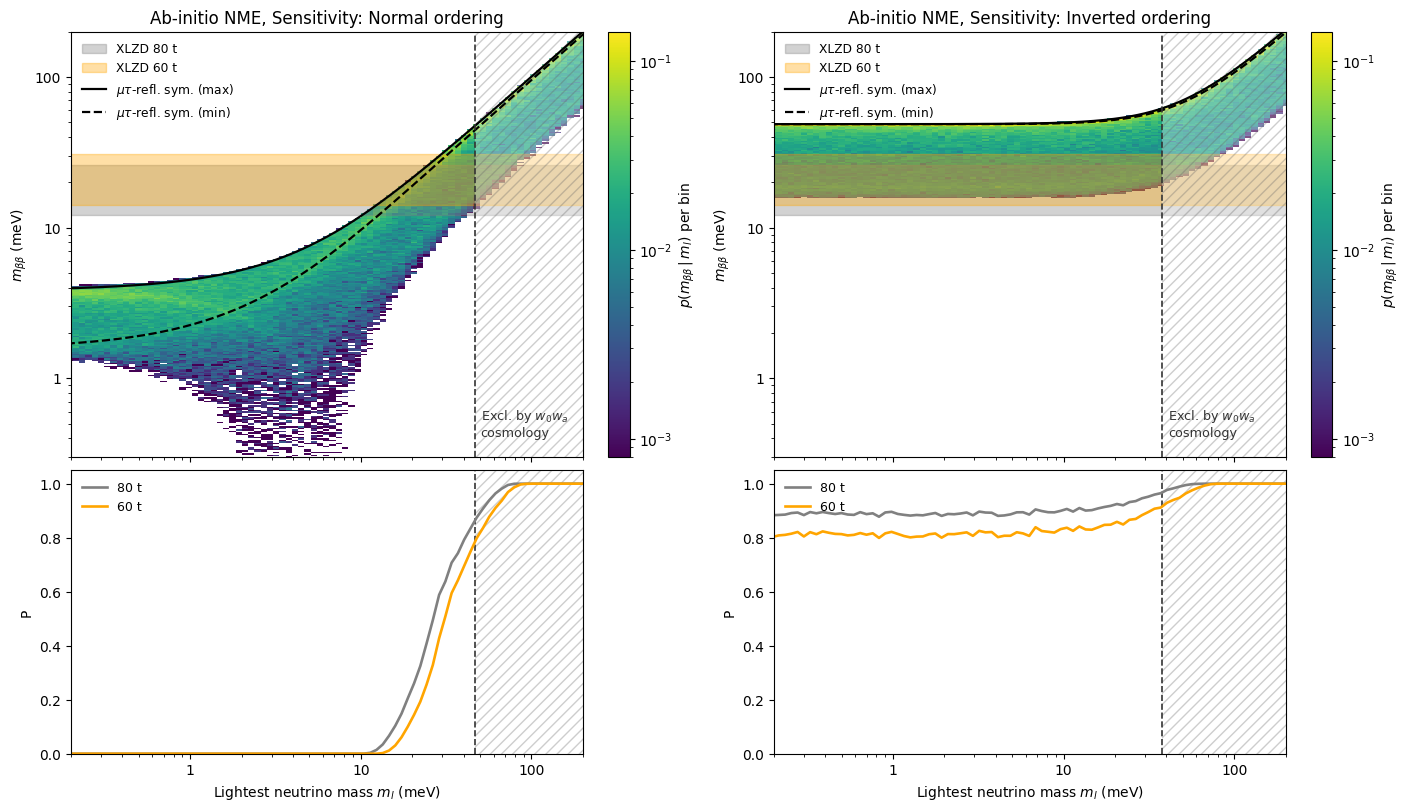

In [9]:
# Plot 1/4: Ab-initio NMEs with sensitivity assumptions
mbb_80t, mbb_60t = build_mbb_bands(nme_ab_initio, mode="sensitivity")
plot_four_panel_for_bands(mbb_80t, mbb_60t, title_prefix="Ab-initio NME, Sensitivity")

## 6b. Ab-initio NMEs — Discovery Potential

Same layout as §6a but with **discovery** half-lives ($T^{1/2}_{80\text{t}} \in [3.81,\,5.76]\times10^{27}$ yr, $T^{1/2}_{60\text{t}} \in [2.64,\,4.06]\times10^{27}$ yr). The bottom panels show $P(\text{discovery} \mid m_l)$ for each mass ordering.

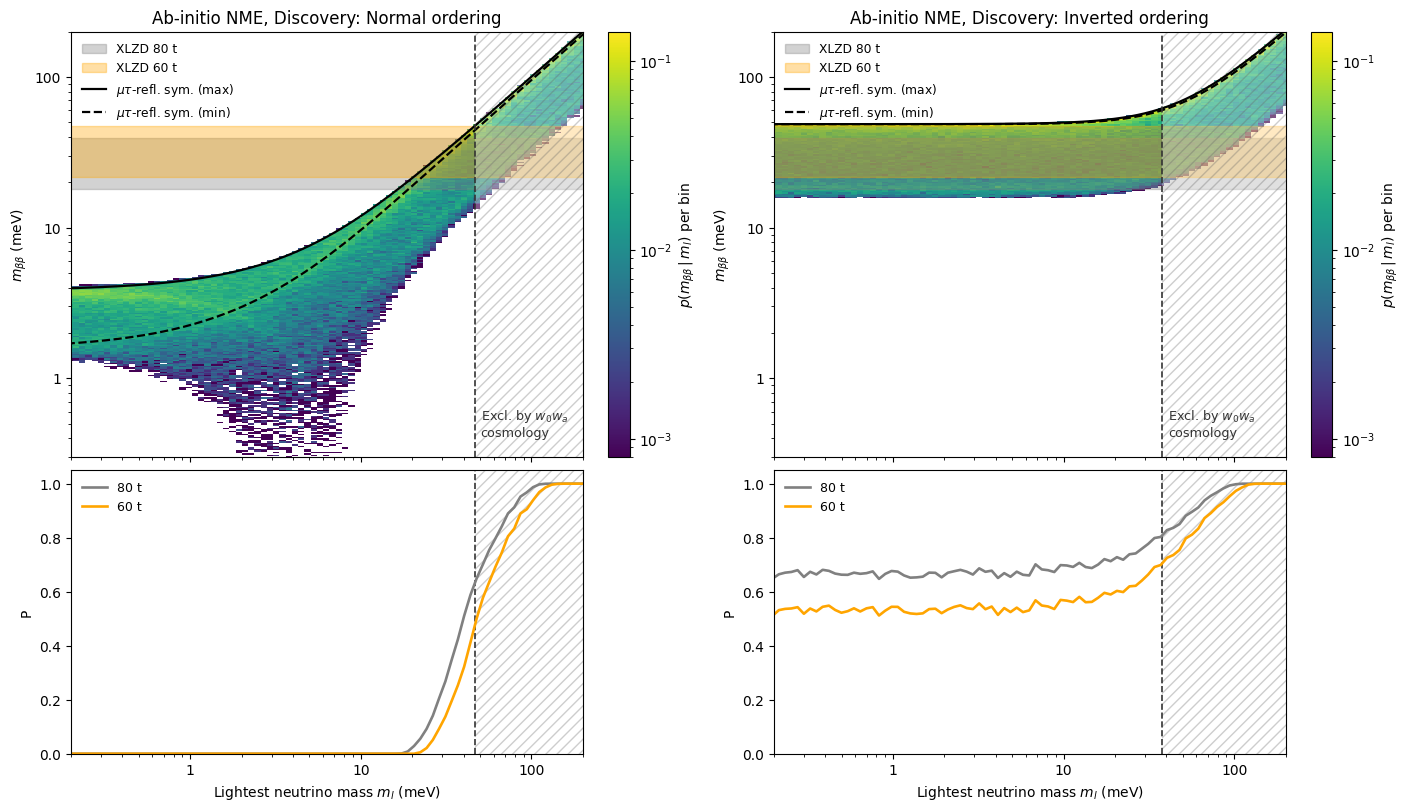

In [10]:
# Plot 2/4: Ab-initio NMEs with discovery assumptions
mbb_80t, mbb_60t = build_mbb_bands(nme_ab_initio, mode="discovery")
plot_four_panel_for_bands(mbb_80t, mbb_60t, title_prefix="Ab-initio NME, Discovery")

## 6c. Phenomenological NMEs — Sensitivity Reach

Sensitivity plot using **phenomenological (QRPA-based) NME** estimates ($|M_{0\nu}| \in [1.98,\,5.06]$). These larger NME values lower the $m_{\beta\beta}$ thresholds, shifting the shaded sensitivity bands downward relative to the ab-initio case.

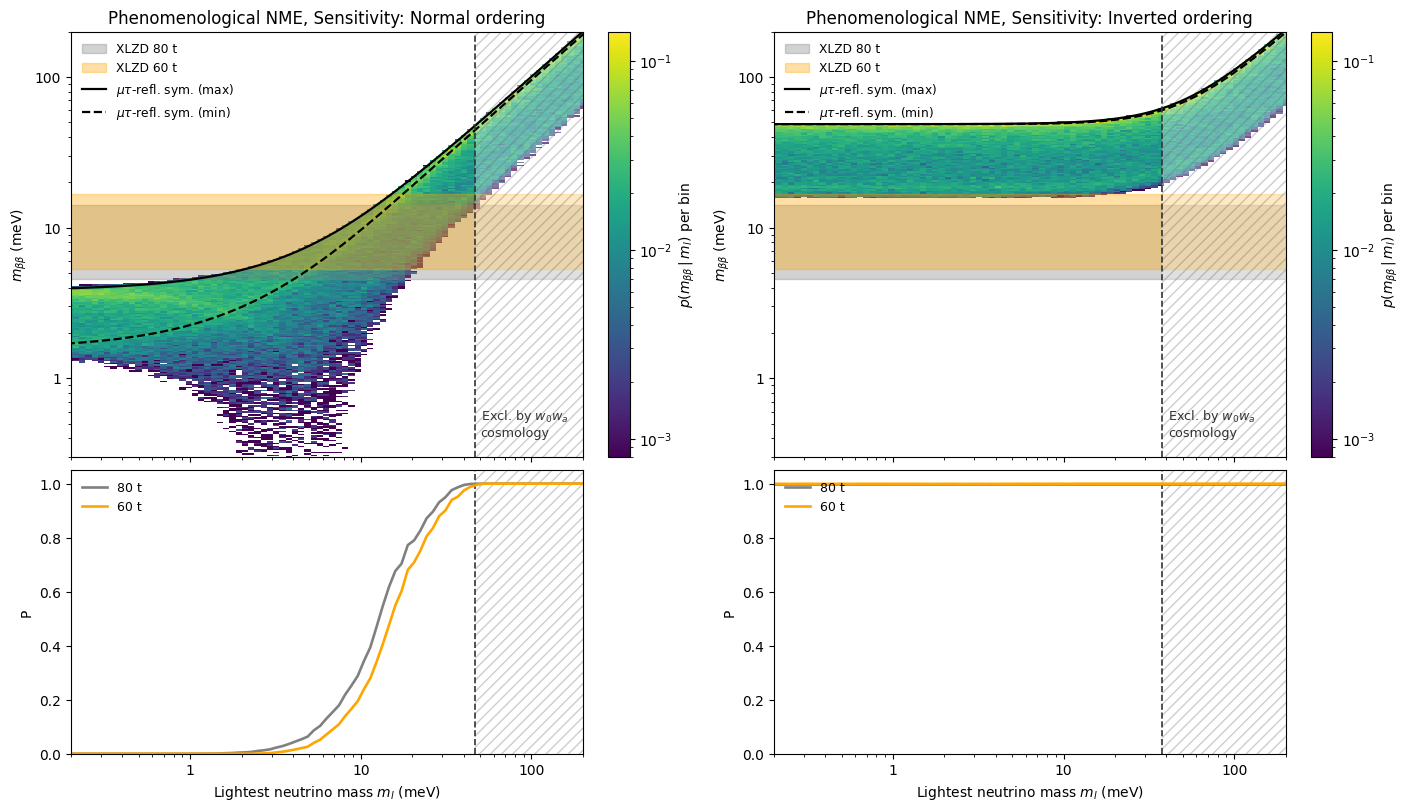

In [11]:
# Plot 3/4: Phenomenological NMEs with sensitivity assumptions
mbb_80t, mbb_60t = build_mbb_bands(nme_pheno, mode="sensitivity")
plot_four_panel_for_bands(mbb_80t, mbb_60t, title_prefix="Phenomenological NME, Sensitivity")

## 6d. Phenomenological NMEs — Discovery Potential

Same as §6c but using **discovery** half-lives. Compare with §6b to see how the much larger phenomenological NME values shift the discovery reach relative to the ab-initio case.

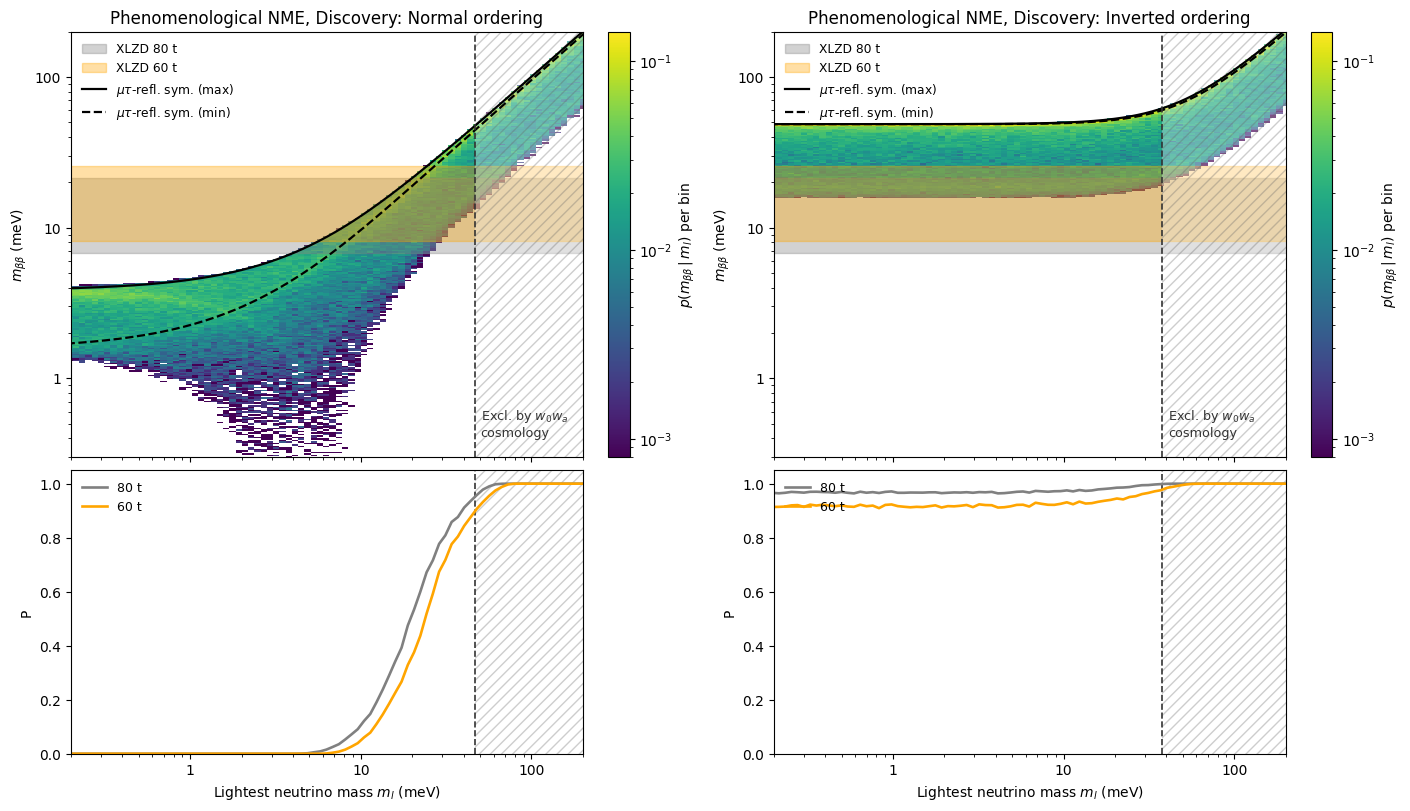

In [12]:
# Plot 4/4: Phenomenological NMEs with discovery assumptions
mbb_80t, mbb_60t = build_mbb_bands(nme_pheno, mode="discovery")
plot_four_panel_for_bands(mbb_80t, mbb_60t, title_prefix="Phenomenological NME, Discovery")

## 7. CP-Conserving / $\mu$-$\tau$ Reflection-Symmetry Phase Curves

Curves tracing $|m_{\beta\beta}|(m_l)$ at best-fit oscillation parameters for the four CP-conserving Majorana phase combinations $(\alpha_1, \alpha_2) \in \{0, \pi\}^2$. Because $|m_{\beta\beta}|$ depends only on $\theta_{12}$, $\theta_{13}$, the mass splittings, and the two Majorana phases $\alpha_1, \alpha_2$ -- the Dirac phase $\delta_{CP}$ and $\theta_{23}$ drop out entirely -- this is also the complete set of predictions from **$\mu$-$\tau$ reflection symmetry**, which fixes $\theta_{23} = \pi/4$, $\delta_{CP} = \pm\pi/2$, and forces the Majorana phases to be CP-conserving without picking out a unique combination among the four. Note that $(0,0)$ and $(\pi,\pi)$ coincide at small $m_l$ (constructive interference, the upper edge of the band), while $(0,\pi)$ and $(\pi,0)$ coincide there too (destructive interference, the cancellation notch visible in the Normal Ordering density plots above). The four curves together exactly bound the Monte Carlo phase-density shown in Section 6, and the (max, min) pair is overlaid directly on those density panels as black solid/dashed lines.


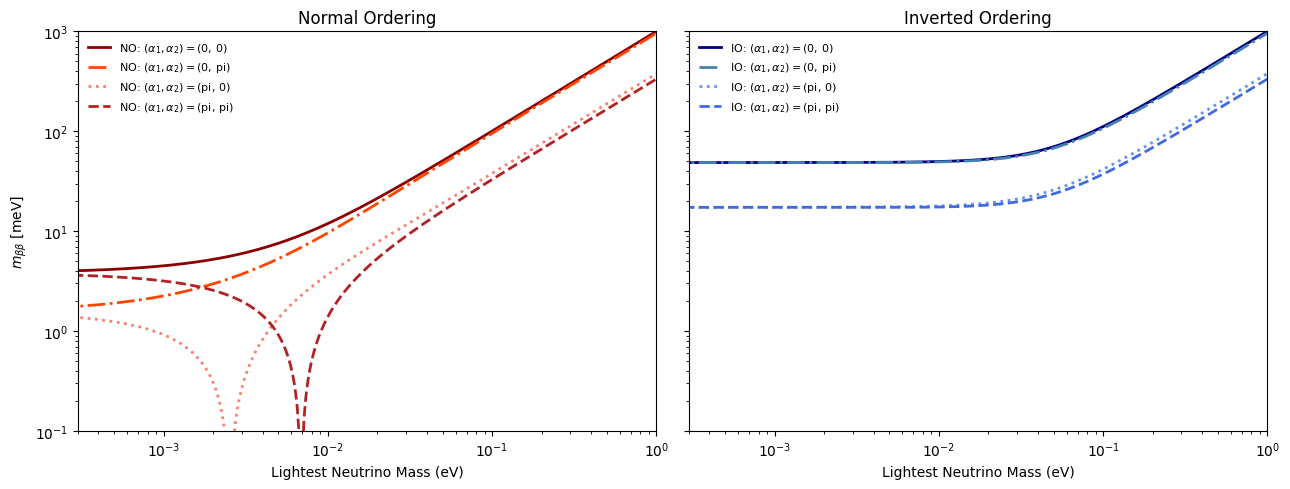

In [13]:
curves_no = lm.cp_conserving_curves(params_dict_NO, "NO", m_l_model_eV)
curves_io = lm.cp_conserving_curves(params_dict_IO, "IO", m_l_model_eV)

styles_no = {
    "(0, 0)": dict(color="darkred", lw=2, ls="-"),
    "(pi, pi)": dict(color="firebrick", lw=2, ls="--"),
    "(0, pi)": dict(color="orangered", lw=2, ls="-."),
    "(pi, 0)": dict(color="salmon", lw=2, ls=":"),
}
styles_io = {
    "(0, 0)": dict(color="navy", lw=2, ls="-"),
    "(pi, pi)": dict(color="royalblue", lw=2, ls="--"),
    "(0, pi)": dict(color="steelblue", lw=2, ls="-."),
    "(pi, 0)": dict(color="cornflowerblue", lw=2, ls=":"),
}

fig, (ax_no, ax_io) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for label, curve in curves_no.items():
    ax_no.plot(m_l_model_eV, curve, label=fr"NO: $(\alpha_1,\alpha_2)=${label}", **styles_no[label])
for label, curve in curves_io.items():
    ax_io.plot(m_l_model_eV, curve, label=fr"IO: $(\alpha_1,\alpha_2)=${label}", **styles_io[label])

for ax, title in [(ax_no, "Normal Ordering"), (ax_io, "Inverted Ordering")]:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3e-4, 1.0)
    ax.set_ylim(1e-1, 1e3)
    ax.set_title(title)
    ax.set_xlabel("Lightest Neutrino Mass (eV)")
    ax.legend(frameon=False, fontsize=8)

ax_no.set_ylabel(r"$m_{\beta\beta}$ [meV]")
plt.tight_layout()
plt.show()
